<a href="https://colab.research.google.com/github/Ivatams/2025-06-25_marketing-demo/blob/main/syntheticControlforA/B_Test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Step 1: Install SyntheticControlMethods
!pip install SyntheticControlMethods

In [2]:
# Step 2: Imports
import pandas as pd
import numpy as np
from SyntheticControlMethods import Synth

In [3]:
# Step 3: Build the dataset
np.random.seed(3)

num_companies = 20
months = pd.date_range(start='2023-01-01', end='2024-04-01', freq='MS')
num_months = len(months)

companies = np.repeat([f"Company_{i}" for i in range(1, num_companies + 1)], num_months)
months_tiled = np.tile(months, num_companies)

company_sizes = np.random.randint(50, 1000, num_companies)
company_sizes = np.repeat(company_sizes, num_months)

subscription_revenue = np.random.normal(8000, 2000, num_companies * num_months)
another_covariate = np.random.uniform(10, 50, num_companies * num_months)
yet_another_covariate = np.random.uniform(100, 200, num_companies * num_months)

df = pd.DataFrame({
    'company': companies,
    'date': months_tiled,
    'subscription_revenue': subscription_revenue,
    'company_size': company_sizes,
    'another_covariate': another_covariate,
    'yet_another_covariate': yet_another_covariate
})

# Apply treatment effect to Company_1 starting January 2024
treatment_start = pd.to_datetime('2024-01-01')
df.loc[(df['company'] == 'Company_1') & (df['date'] >= treatment_start), 'subscription_revenue'] += 5000

# Track relative timeline index per company
df['month_num'] = df.groupby('company').cumcount() + 1

# Dynamically extract treatment period index
treatment_period = int(df[df['date'] == treatment_start]['month_num'].values[0])

print(f"Treatment period index: {treatment_period}")
print(df.head())

Treatment period index: 13
     company       date  subscription_revenue  company_size  \
0  Company_1 2023-01-01           5372.270493           924   
1  Company_1 2023-02-01           9769.244761           924   
2  Company_1 2023-03-01           9762.636084           924   
3  Company_1 2023-04-01          11419.146127           924   
4  Company_1 2023-05-01           8100.067284           924   

   another_covariate  yet_another_covariate  month_num  
0          22.204455             116.617303          1  
1          34.892505             162.080220          2  
2          37.372067             197.827328          3  
3          31.078490             158.607154          4  
4          23.659065             129.516716          5  


In [4]:
# Step 3b: Robust scipy patch — auto-finds and patches the correct internal module
import numpy as np
import scipy.optimize as _scipy_opt
from scipy.optimize import minimize as _orig_minimize
import sys

def _patched_minimize(fun, x0, *args, **kwargs):
    x0 = np.array(x0).flatten()
    return _orig_minimize(fun, x0, *args, **kwargs)

# Patch at scipy level
_scipy_opt.minimize = _patched_minimize

# Auto-find and patch all loaded SyntheticControlMethods submodules
import importlib, pkgutil
import SyntheticControlMethods as _pkg

for finder, modname, ispkg in pkgutil.walk_packages(
    path=_pkg.__path__,
    prefix=_pkg.__name__ + ".",
    onerror=lambda x: None
):
    try:
        mod = importlib.import_module(modname)
        if hasattr(mod, "minimize"):
            mod.minimize = _patched_minimize
            print(f"Patched: {modname}")
    except Exception as e:
        print(f"Could not patch {modname}: {e}")

print("Patch complete")

Patched: SyntheticControlMethods.optimize
Patch complete


In [5]:
# Step 4: Fit the Synthetic Control model
sc = Synth(
    dataset=df,
    outcome_var="subscription_revenue",
    id_var="company",
    time_var="month_num",
    treatment_period=treatment_period,
    treated_unit="Company_1",
    n_optim=30,
    pen=0,
    exclude_columns="date"
)

/tmp/ipykernel_19894/2609476175.py:9: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  return _orig_minimize(fun, x0, *args, **kwargs)


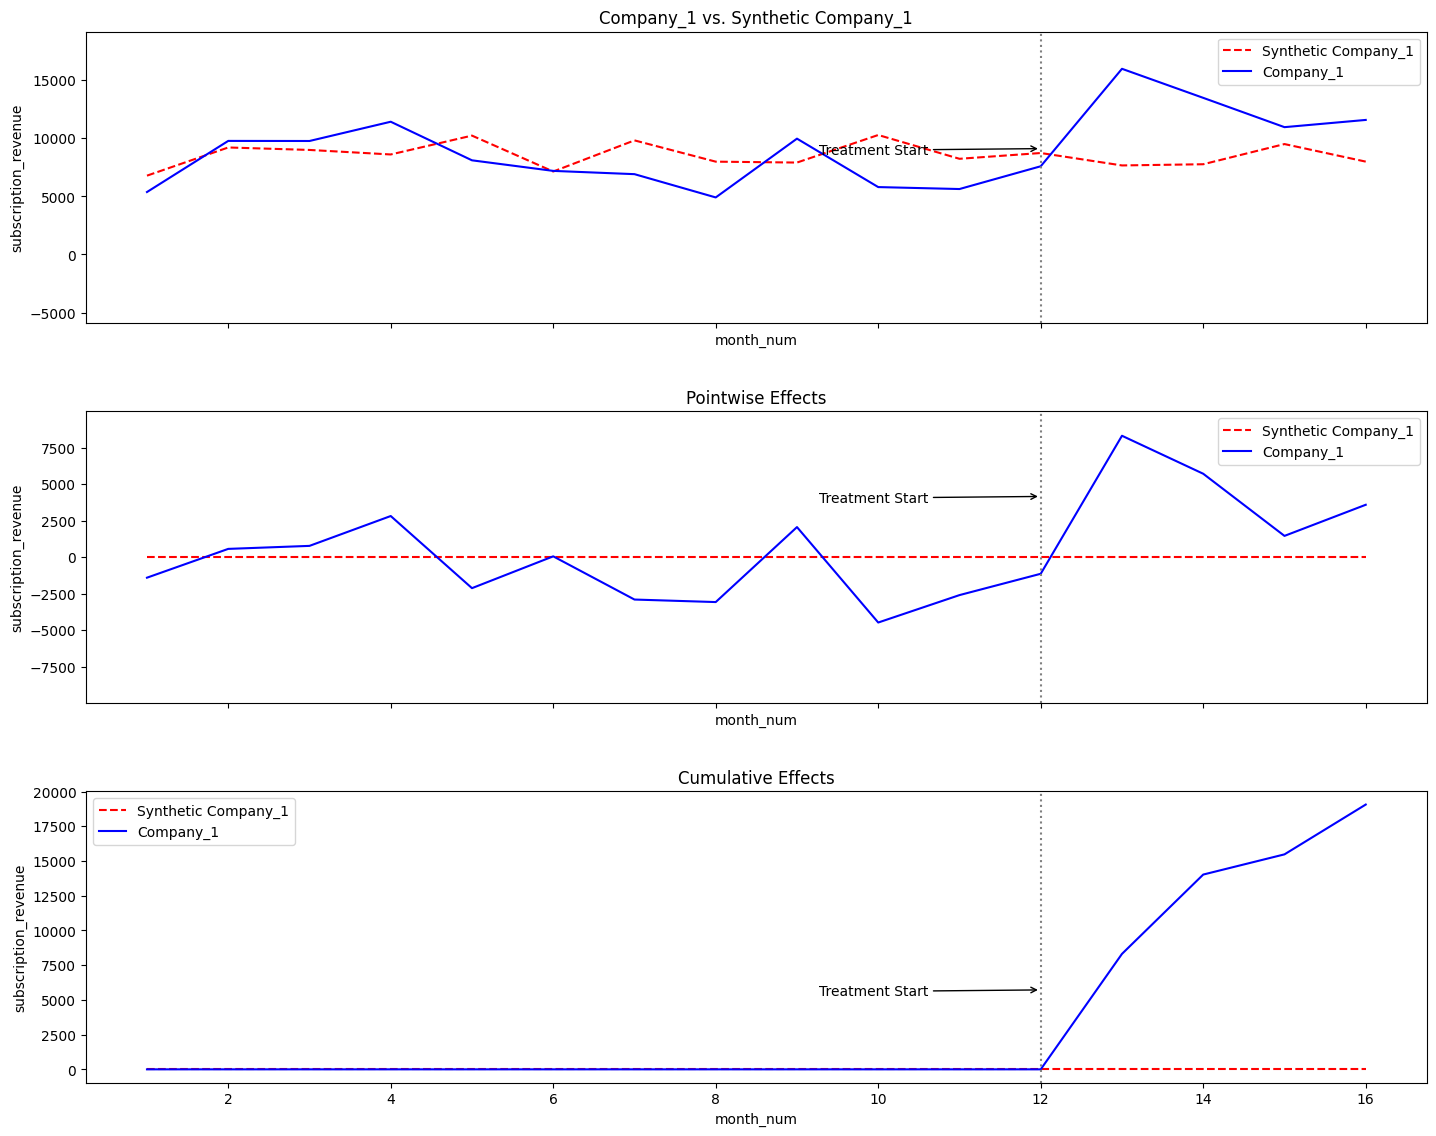

In [6]:
# Step 5: Plot the results
sc.plot(["original", "pointwise", "cumulative"],
        treated_label="Company_1",
        synth_label="Synthetic Company_1",
        treatment_label="Treatment Start")

In [7]:
print(sc.original_data.weight_df)

              Weight
Company_13  0.578241
Company_17  0.421759


In [8]:
print(sc.original_data.rmspe_df)

        unit    pre_rmspe   post_rmspe  post/pre
0  Company_1  2338.550052  5401.265638  2.309664


/tmp/ipykernel_19894/2609476175.py:9: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  return _orig_minimize(fun, x0, *args, **kwargs)


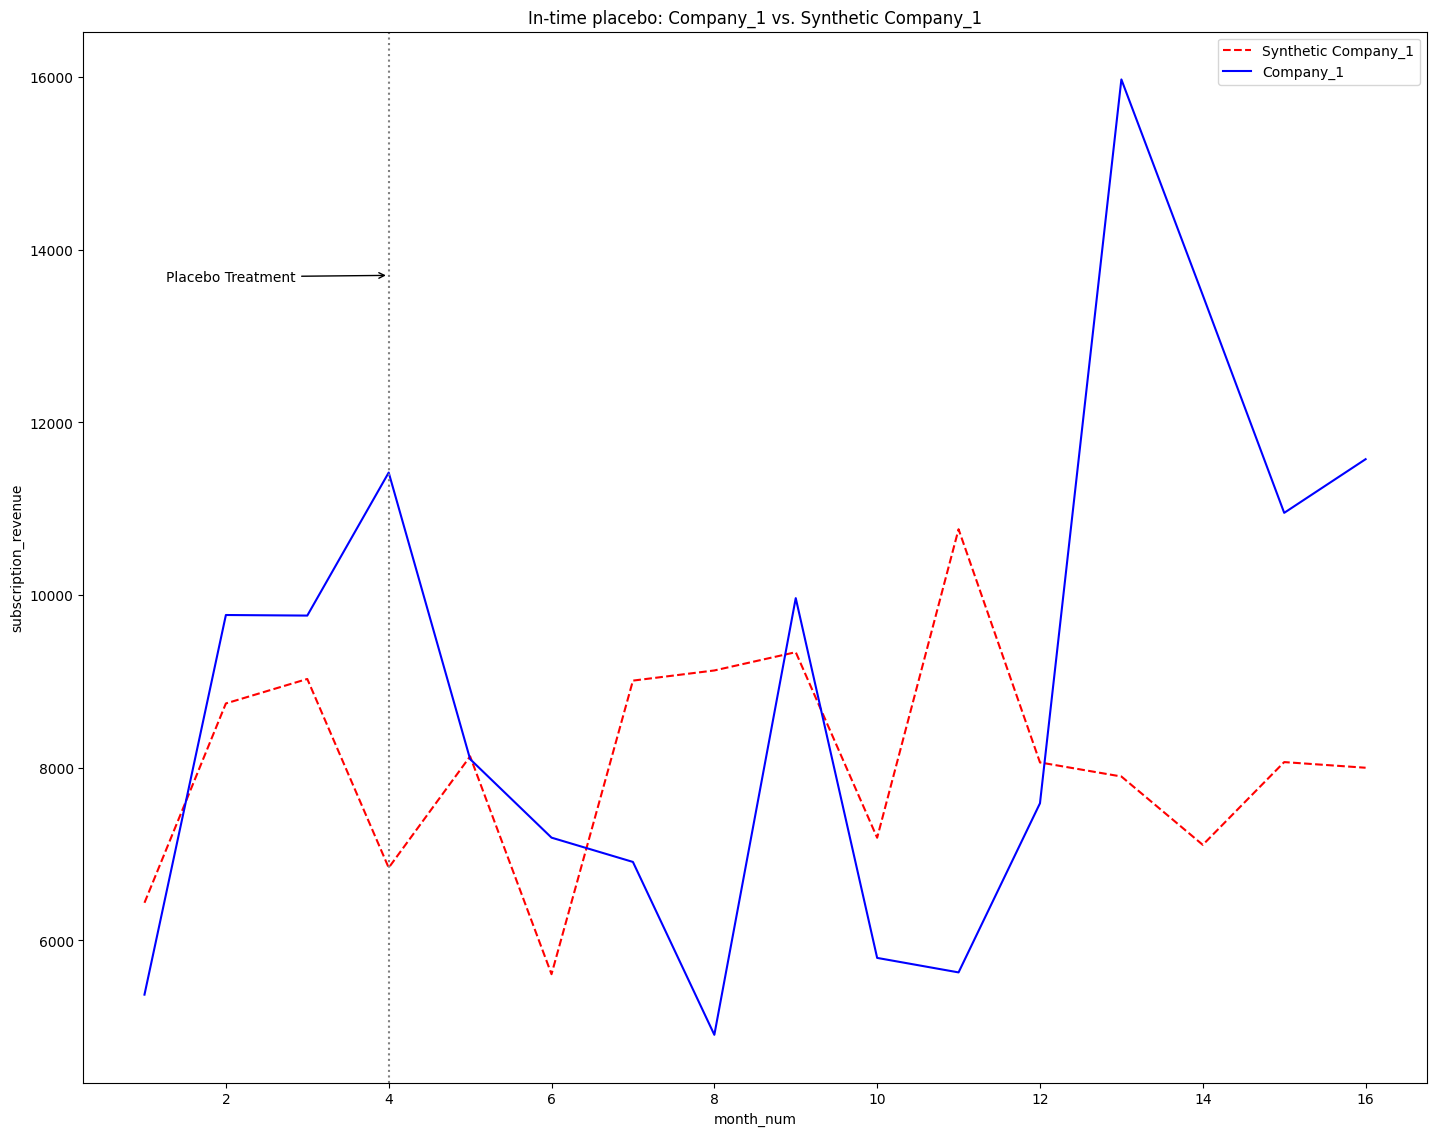

In [9]:
sc.in_time_placebo(4)

sc.plot(['in-time placebo'],
        treated_label="Company_1",
         synth_label="Synthetic Company_1")

In [10]:
sc.in_space_placebo(5)

/tmp/ipykernel_19894/2609476175.py:9: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  return _orig_minimize(fun, x0, *args, **kwargs)


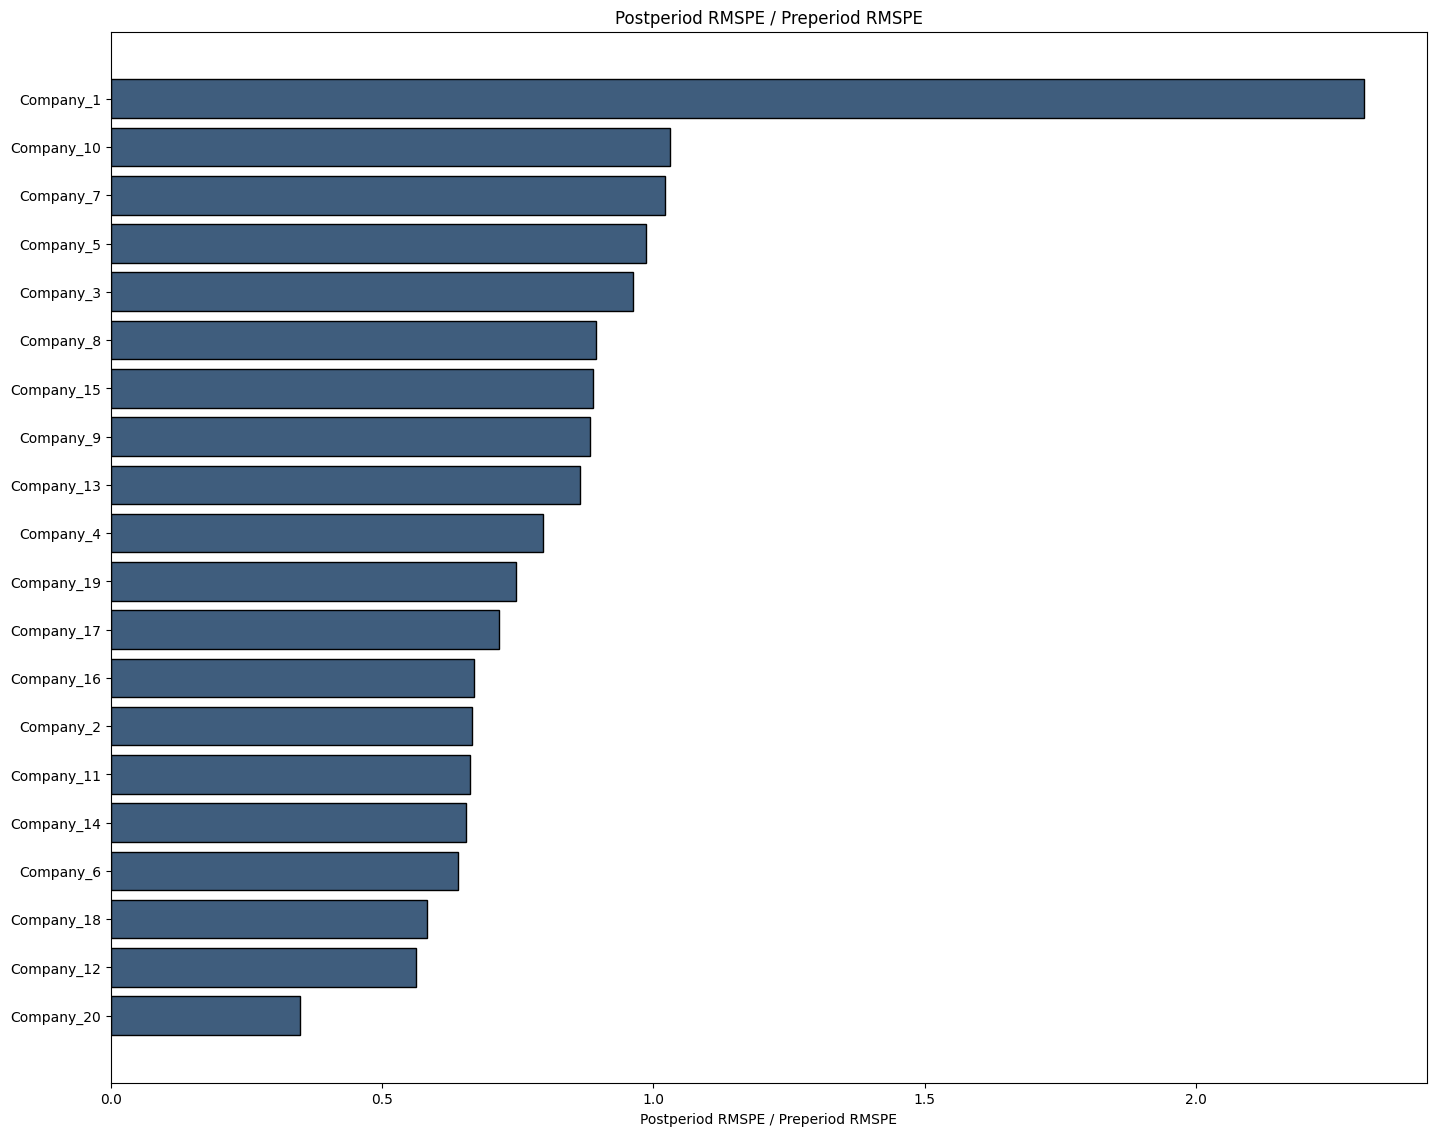

In [11]:
sc.plot(['rmspe ratio'])

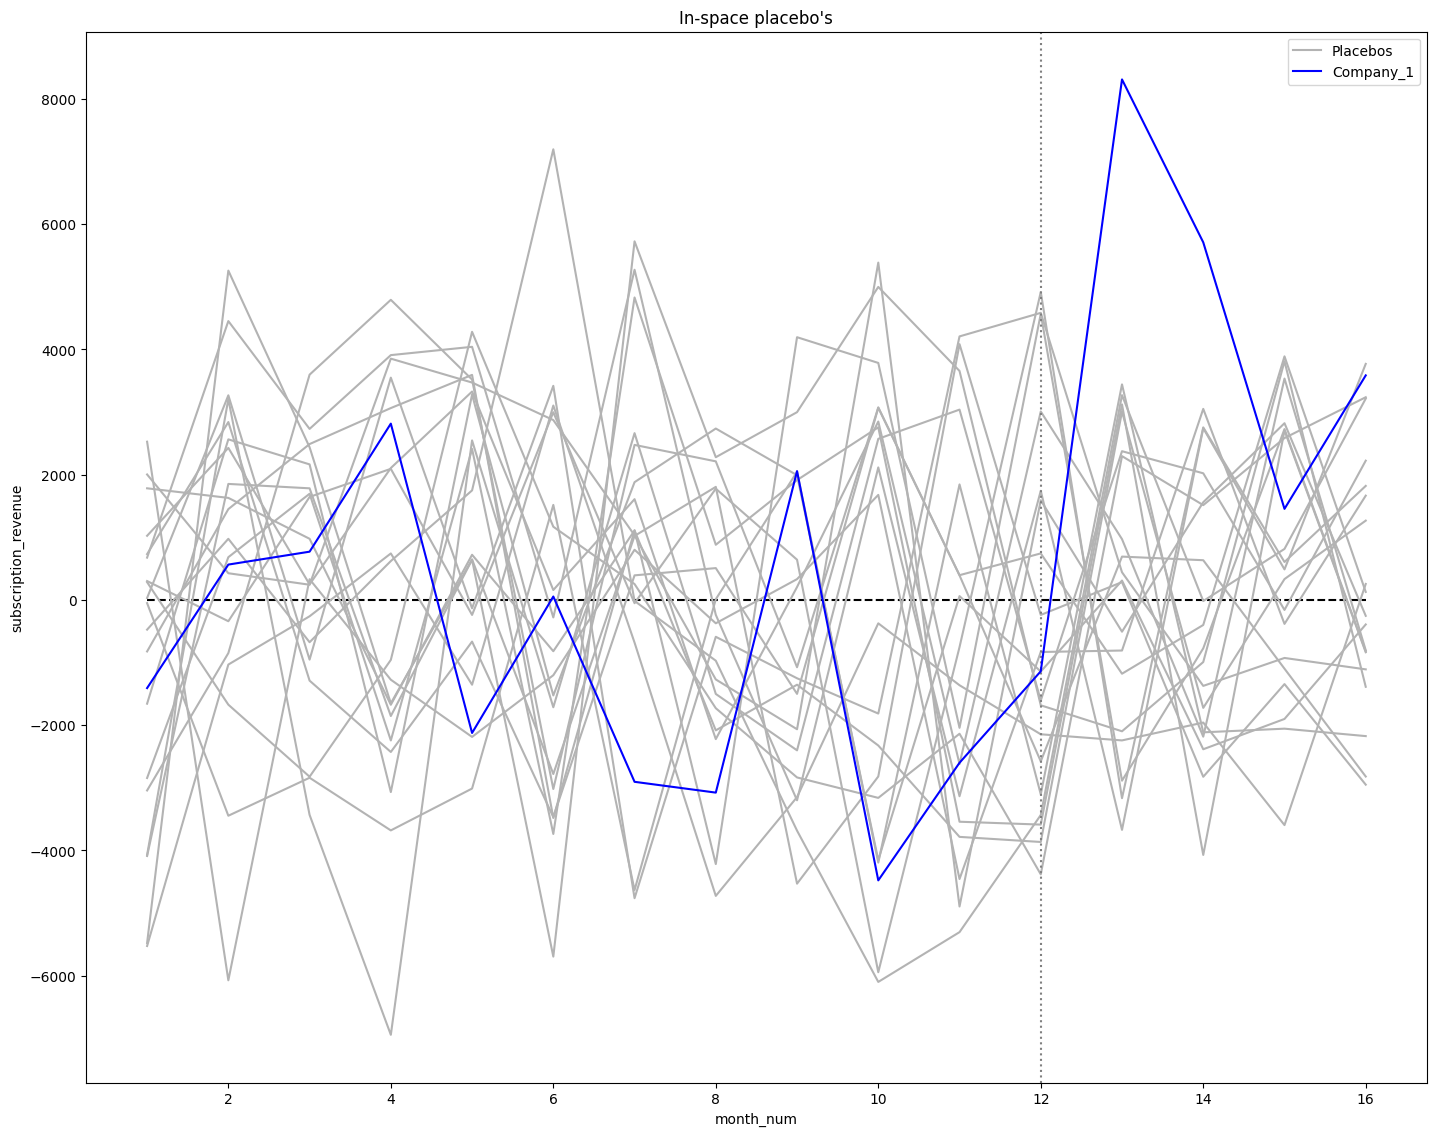

In [12]:
sc.plot(['in-space placebo'],
        treated_label="Company_1",
        synth_label="Synthetic Company_1")